Data: https://networks.skewed.de/net/celegans_2019/files/hermaphrodite_chemical_synapse.csv.zip

In [1]:
import pandas as pd
import networkx as nx

edges = pd.read_csv("data/hermaphrodite_chemical_synapse/edges.csv")
edges.head()

,# source,target,synapses
0,0,2,2
1,0,4,1
2,1,3,1
3,1,4,1
4,1,8,1


## edges.csv

**Columns:**
- source: the presynaptic neuron
- target: the postsynaptic neuron
- synapses: the number of individual synaptic contacts
  - ↑ synpases → strongly connected

In [7]:
# change column names
edges = edges.rename(columns={"# source": "source"})
edges.columns = edges.columns.str.strip()

G = nx.from_pandas_edgelist(
    edges,
    source="source",
    target="target",
    edge_attr="synapses",
    create_using=nx.DiGraph
)

print(G.number_of_nodes(), "neurons")
print(G.number_of_edges(), "connections")

357 neurons
3701 connections


## Degree Distribution: In-Degree vs. Out-Degree

Since this is a **directed** graph (a chemical synapse sends signal *from* one neuron *to* another, not both ways), each neuron has two separate degree values:

- **In-degree**: the number of other neurons that synapse *onto* this neuron
  ↑ in-degree → integration point

- **Out-degree**: the number of other neurons this neuron synapses *onto*
   ↑ out-degree → distribution point.

### Mean in/out-degree
The average across all neurons — gives a sense of "how connected is a typical neuron" in this network.

Note: for any directed graph, **mean in-degree always equals mean out-degree** (every edge counts as one outgoing connection for its source and one incoming connection for its target, so the totals must match).

### Max in/out-degree
Identifies potential **hub neurons**:
- max in-degree: the most extreme integrators
- max out-degree: the most extreme broadcasters

In the real C. elegans connectome, neurons like AVA, AVB, and PVC are well-known high-degree command interneurons involved in coordinating locomotion — worth checking later whether the highest-degree nodes in this data correspond to neurons with known functional roles.

In [8]:
import numpy as np

in_degress = [d for _, d in G.in_degree()]
out_degress = [d for _, d in G.out_degree()]

print("Mean in-degree:", np.mean(in_degress))
print("Mean out-degree:", np.mean(out_degress))
print("Max in-degree:", max(in_degress))
print("Max out-degree:", max(out_degress))

Mean in-degree: 10.366946778711485
Mean out-degree: 10.366946778711485
Max in-degree: 45
Max out-degree: 62


## Small-World Network Analysis

To test this, we compare two metrics against a random graph baseline of the same size:

- **Clustering coefficient**: how tightly-knit a neuron's local neighborhood is
  (do its neighbors also connect to each other?)
- **Average shortest path length**: how many synaptic hops, on average, it takes
  to get from any neuron to any other neuron

A small-world network shows **much higher clustering** than random, while keeping
**path length comparable** to random — meaning local circuits are tightly organized,
but the network as a whole still allows fast signal propagation.

## Network
- **Regular/lattice network:** every node only connects to its nearby neighbors (like people only knowing their immediate neighbors on a street). Highly clustered, but it takes many hops to reach someone far away.
- **Random network:** connections are scattered randomly across the whole network. Short paths between any two nodes, but no local structure — a node's neighbors are unlikely to know each other.
- **Small-world network:** between those two extremes
  - **High clustering** = tightly-knit local neighborhoods.
  - **Short average path length** = information travels efficiently.
    Path length: how many edges (hops) you cross to get from one neuron to another.

In [10]:
# Convert a copy to undirected
G_undirected = G.to_undirected()

# Check whether the network is fully connected
print("Is connected:", nx.is_connected(G_undirected))

# If disconnected, use the largest connected component and ignore small leftovers
if not nx.is_connected(G_undirected):
    # nx.connected_components() returns groups of mutually-reachable nodes.
    largest_cc = max(nx.connected_components(G_undirected), key=len)
    G_cc = G_undirected.subgraph(largest_cc).copy() # cc represents for "connected component"
    print("Largest component size:", G_cc.number_of_nodes())
else:
    G_cc = G_undirected

# Compute the two small-world metrics
clustering = nx.average_clustering(G_cc)
avg_path_length = nx.average_shortest_path_length(G_cc)

print("Clustering coefficient:", clustering)
print("Average shortest path length:", avg_path_length)

Is connected: False
Largest component size: 313
Clustering coefficient: 0.32639477969739716
Average shortest path length: 2.47886458589334


## Is the undirected model worth?

- The undirected small-world analysis isn't claiming to model how information actually flows through the circuit.
- It's asking a purely **structural/topological** question:
  - "is the underlying wiring skeleton organized efficiently — local clusters bridged by shortcuts — regardless of which way signals travel along it?" 

In [11]:
# Build a random graph with the SAME size for comparison
n = G_cc.number_of_nodes()   # same neuron count
m = G_cc.number_of_edges()   # same connection count

# gnm_random_graph(n, m) builds a graph with exactly n nodes and m edges,
# placed uniformly at random — this is the "null model" / baseline.
G_random = nx.gnm_random_graph(n, m)

clustering_random = nx.average_clustering(G_random)
avg_path_length_random = nx.average_shortest_path_length(G_random)

print("Random clustering:", clustering_random)
print("Random path length:", avg_path_length_random)


Random clustering: 0.05863863587719686
Random path length: 2.2366674858687636


**Clustering (C)**: 0.326 (real) vs. 0.059 (random) — the real network's clustering is about 5.6x higher than random. Neurons form tight local clusters far more than random wiring would produce.

**Path length (L)**: 2.48 (real) vs. 2.24 (random) — only about 11% longer than random, despite that huge clustering difference.

That combination — dramatically higher clustering, nearly-unchanged path length — is exactly the small-world pattern.

**small-world coefficient (σ)** = (C/C_rand) / (L/L_rand)

In [12]:
# Calculate small-world coefficient
sigma = (clustering / clustering_random) / (avg_path_length / avg_path_length_random)
print("Small-world coefficient (sigma):", sigma)

Small-world coefficient (sigma): 5.022361474043903


**σ > 1** indicates small-world structure — roughly 5 is a strong signal.

## Betweenness Centrality: Finding Bridge Neurons


**Betweenness centrality**: how often a neuron lies *on the shortest path* between other pairs of neurons.
- nodes with ↑ betweenness centrality: acts as a bottleneck — the one link connecting two otherwise-separate parts of the circuit.

**Note:** **degree —** how many direct connections a neuron has.

**Why this matters for our small-world result:**
- High clustering alone doesn't guarantee short overall path lengths — something has to bridge the separate clusters.
- Betweenness centrality identifies exactly which neurons are doing that bridging work.
- **Small-world findings:** a small number of neurons with disproportionately high betweenness relative to everyone else.

**Comparing to degree:** it's worth checking whether the highest-betweenness neurons are the *same* as the highest-degree neurons from earlier, or different — a neuron can be a critical bridge without having unusually many direct connections, and vice versa.

In [20]:
betweenness = nx.betweenness_centrality(G_cc)

# Sort neurons by betweenness, show the top 10
top_betweenness = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 neurons by betweenness centrality:")
for node, score in top_betweenness:
    print(f"  Node {node}: {score:.4f}")


Top 10 neurons by betweenness centrality:
  Node 215: 0.0743
  Node 216: 0.0730
  Node 101: 0.0536
  Node 208: 0.0369
  Node 176: 0.0360
  Node 209: 0.0347
  Node 214: 0.0314
  Node 200: 0.0269
  Node 217: 0.0231
  Node 445: 0.0222


> **`sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]`**
> 
> `betweenness.items()`
> 
> `betweenness` is a dictionary mapping each node to its centrality score, e.g. `{0: 0.012, 1: 0.045, 2: 0.001, ...}`. `.items()` converts this into a list of `(key, value)` tuples: `[(0, 0.012), (1, 0.045), (2, 0.001), ...]` — i.e., `(node, score)` pairs.
> 
> `sorted(..., key=lambda x: x[1], ...)`
> 
> `sorted()` normally sorts tuples by their first element by default (which here would sort by node ID — not useful). The `key=lambda x: x[1]` tells it: "for each tuple x, sort based on `x[1]`" — that's the score (the second element, index 1), not the node ID. So this sorts the list by betweenness score instead.
> 
> `reverse=True`
> 
> `sorted()` sorts ascending (smallest first) by default. `reverse=True` flips that to descending, so the highest scores come first — which is what you want when looking for "top" neurons.
> 
> `[:10]`
> 
> Standard list slicing — takes just the first 10 elements of the now-sorted list, i.e., the 10 neurons with the highest betweenness scores.

Matplotlib is building the font cache; this may take a moment.


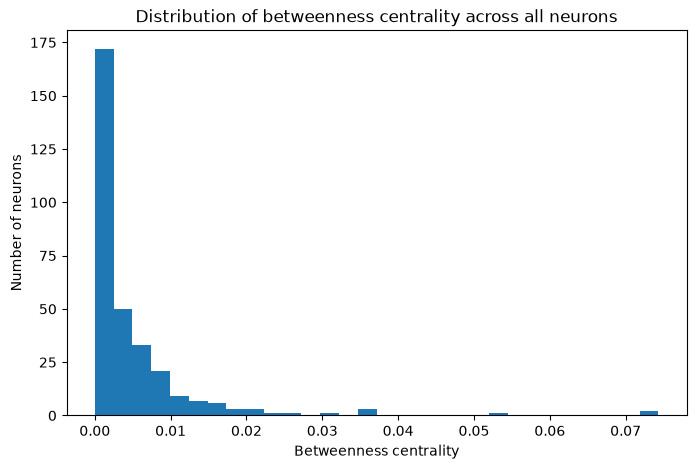

In [ ]:
# Histogram of betweenness across ALL neurons
import matplotlib.pyplot as plt

all_scores = list(betweenness.values())

plt.figure(figsize=(8, 5))
plt.hist(all_scores, bins=30)
plt.xlabel("Betweenness centrality")
plt.ylabel("Number of neurons")
plt.title("Distribution of betweenness centrality across all neurons")
plt.show()

In [19]:
# Network diagram with node size scaled by betweenness
import plotly.graph_objects as go

pos_3d = nx.spring_layout(G_cc, dim=3, seed=42)

# Edges: Plotly draws lines by giving x/y/z coordinate lists with None as a "pen up" separator between segments
edge_x, edge_y, edge_z = [], [], []
for u, v in G_cc.edges():
    x0, y0, z0 = pos_3d[u]
    x1, y1, z1 = pos_3d[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]
    edge_z += [z0, z1, None]

edge_trace = go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    mode="lines",
    line=dict(color="lightgray", width=1),
    hoverinfo="none"
)

# Nodes: size/color scaled by betweenness centrality
node_x = [pos_3d[n][0] for n in G_cc.nodes()]
node_y = [pos_3d[n][1] for n in G_cc.nodes()]
node_z = [pos_3d[n][2] for n in G_cc.nodes()]
node_betweenness = [betweenness[n] for n in G_cc.nodes()]

node_trace = go.Scatter3d(
    x=node_x, y=node_y, z=node_z,
    mode="markers",
    marker=dict(
        size=6,
        color=node_betweenness,
        colorscale="Viridis",
        colorbar=dict(title="Betweenness"),
    ),
    text=[str(n) for n in G_cc.nodes()],
    hoverinfo="text"
)

fig = go.Figure(data=[edge_trace, node_trace])
fig.update_layout(
    title="C. elegans connectome (3D, node color = betweenness centrality)",
    showlegend=False,
    scene=dict(xaxis=dict(visible=False), yaxis=dict(visible=False), zaxis=dict(visible=False))
)
fig.show()


## Community Detection

Community detection asks a network-wide question: does this graph naturally partition into densely-connected sub-groups, with comparatively sparse connections *between* groups?

### Modularity-based community detection
#### Modularity
- The formula's core idea:
  1. Is there actually an edge between them? (yes = 1, no = 0)
  2. How many edges would you expect between these two specific neurons just by random chance?
- Interpretation:
  - above ~0.3: meaningfully clustered
  - near 0: random

#### Mechanism
It searches for a partition of nodes into groups that maximizes "modularity"

#### Algorhithm for the best grouping
It starts with every neuron in its own tiny community, then repeatedly merges the pair of communities that increases modularity the most, over and over, stopping once no further merge would help. — not guaranteed to find the mathematically optimal partition.

#### Caveat
It can struggle to detect small communities buried inside large networks.

### Interpretation
If the detected communities turn out to loosely align with known functional groupings (e.g., sensory neurons, motor neurons, specific ganglia), that would suggest the wiring topology alone (with no biological labels used) can recover meaningful functional organization.

In [22]:
from networkx.algorithms import community

# greedy_modularity_communities returns a list of sets, each set = one community
communities = community.greedy_modularity_communities(G_cc)

print(f"Number of communities found: {len(communities)}")
for i, comm in enumerate(communities):
    print(f"Community {i}: {len(comm)} neurons")

# Modularity score
modularity_score = community.modularity(G_cc, communities)
print(f"Modularity score: {modularity_score:.4f}")


Number of communities found: 3
Community 0: 138 neurons
Community 1: 124 neurons
Community 2: 51 neurons
Modularity score: 0.3917


Number of communities found: 3
Community 0: 138 neurons
Community 1: 124 neurons
Community 2: 51 neurons
Modularity score: 0.3917


## Cross-Reference

In [24]:
nodes_df = pd.read_csv("data/hermaphrodite_chemical_synapse/nodes.csv")
nodes_df.columns = nodes_df.columns.str.strip()
print(nodes_df.columns.tolist())
nodes_df.head()

['# index', 'node_type', 'node_subtype', 'name', '_pos']


,# index,node_type,node_subtype,name,_pos
0,0,PHARYNX,NaN,I1L,"array([-11.44074767, -10.00165623])"
1,1,PHARYNX,NaN,I1R,"array([-12.19539363, -10.21156192])"
2,2,PHARYNX,NaN,I2L,"array([-11.31182705, -9.13559368])"
3,3,PHARYNX,NaN,I2R,"array([-13.13057984, -10.89412273])"
4,4,PHARYNX,NaN,I3,"array([-11.82550633, -8.95718572])"
